In [23]:
import pandas as pd
import numpy as np

# Dataset sintético: alumnos de una academia online (primeras 4 semanas)
# Cada alumno tiene un perfil + comportamiento + un target abandono.
np.random.seed(42)
n = 1200

edad = np.clip(np.random.normal(28, 7, n), 16, 60).round(0).astype(int)
nivel_previo = np.random.choice(['ninguno', 'basico', 'medio', 'avanzado'], size=n, p=[0.45, 0.30, 0.18, 0.07])
modalidad = np.random.choice(['part_time', 'full_time'], size=n, p=[0.62, 0.38])
horas_semana = np.clip(np.random.normal(8, 4, n), 0, 30).round(1)
ejercicios_completados = np.clip(np.random.poisson(12, n), 0, 60)
notas_avg = np.clip(np.random.normal(6.5, 1.8, n), 0, 10).round(1)
asistencias_directos = np.clip(np.random.poisson(3, n), 0, 12)
preguntas_foro = np.clip(np.random.poisson(2, n), 0, 30)
dias_desde_ultima_conexion = np.clip(np.random.exponential(4, n), 0, 30).round(0).astype(int)

# Probabilidad de abandono modelada con señales realistas
prob = 0.18
prob = prob + np.where(horas_semana < 4, 0.30, 0.0)
prob = prob + np.where(ejercicios_completados < 5, 0.25, 0.0)
prob = prob + np.where(dias_desde_ultima_conexion > 7, 0.30, 0.0)
prob = prob + np.where(notas_avg < 5, 0.20, 0.0)
prob = prob - np.where(asistencias_directos >= 4, 0.15, 0.0)
prob = prob - np.where(preguntas_foro >= 3, 0.10, 0.0)
prob = prob + np.where(nivel_previo == 'ninguno', 0.05, 0.0)
prob = np.clip(prob, 0.02, 0.95)
abandono = (np.random.random(n) < prob).astype(int)

# Introducimos huecos realistas
notas_avg_nan = notas_avg.copy()
notas_avg_nan[np.random.choice(n, size=64, replace=False)] = np.nan
nivel_previo_nan = nivel_previo.copy().astype(object)
nivel_previo_nan[np.random.choice(n, size=18, replace=False)] = np.nan

df = pd.DataFrame({
    'alumno_id': range(1, n+1),
    'edad': edad,
    'nivel_previo': nivel_previo_nan,
    'modalidad': modalidad,
    'horas_semana': horas_semana,
    'ejercicios_completados': ejercicios_completados,
    'notas_avg': notas_avg_nan,
    'asistencias_directos': asistencias_directos,
    'preguntas_foro': preguntas_foro,
    'dias_desde_ultima_conexion': dias_desde_ultima_conexion,
    'abandono': abandono,
})

print(f"Dataset cargado: {df.shape[0]} alumnos, {df.shape[1]} columnas")
print(f"Tasa de abandono: {df['abandono'].mean():.1%}")
print(f"\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Dataset cargado: 1200 alumnos, 11 columnas
Tasa de abandono: 24.8%

Valores nulos:
nivel_previo    18
notas_avg       64
dtype: int64


In [24]:
# EJERCICIO 1: Exploración inicial (EDA)
# Audita el dataset antes de modelar

# TODO: Mostrar las primeras filas y la información de columnas
print(df.head(),"\n")
print(df.info(),"\n")

# TODO: Contar nulos
num_numlos = df.isnull().sum()
print(num_numlos, "\n")

# TODO: Tasa de abandono global
tasa_abanadono = df['abandono'].mean()
print(tasa_abanadono , "\n")

# TODO: Tasa de abandono por nivel_previo y por modalidad
tasa_nivel = df.groupby('nivel_previo')['abandono'].mean()
print(round(tasa_nivel, 2),"\n")

tasa_modalidad = df.groupby('modalidad')['abandono'].mean()
print(round(tasa_modalidad, 2),"\n")

# TODO: Correlación entre features numéricas y abandono
#He visto en la carga del dataset cuals son numericas ya pero aun asi voy a revisarlas por codigo
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
print(columnas_numericas, "\n")

#alumno_id y abandono son un identificador y el target asi que no tiene sentido hacer la correlación
columnas_numericas = ['edad', 'horas_semana', 'ejercicios_completados', 'notas_avg', 'asistencias_directos', 'preguntas_foro', 'dias_desde_ultima_conexion']
print(df[columnas_numericas + ['abandono']].corr())


   alumno_id  edad nivel_previo  modalidad  horas_semana  \
0          1    31      ninguno  full_time           6.1   
1          2    27       basico  full_time           5.6   
2          3    33     avanzado  part_time          10.0   
3          4    39       basico  full_time           6.6   
4          5    26        medio  part_time           7.4   

   ejercicios_completados  notas_avg  asistencias_directos  preguntas_foro  \
0                      10        9.5                     3               1   
1                      15        4.9                     7               1   
2                      16        6.8                     4               4   
3                      11        5.3                     0               3   
4                       9        7.6                     2               3   

   dias_desde_ultima_conexion  abandono  
0                           2         0  
1                           2         0  
2                          12         0  
3 

/tmp/ipykernel_5412/2063748395.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(datos_box, labels=niveles)


Gráficos generados


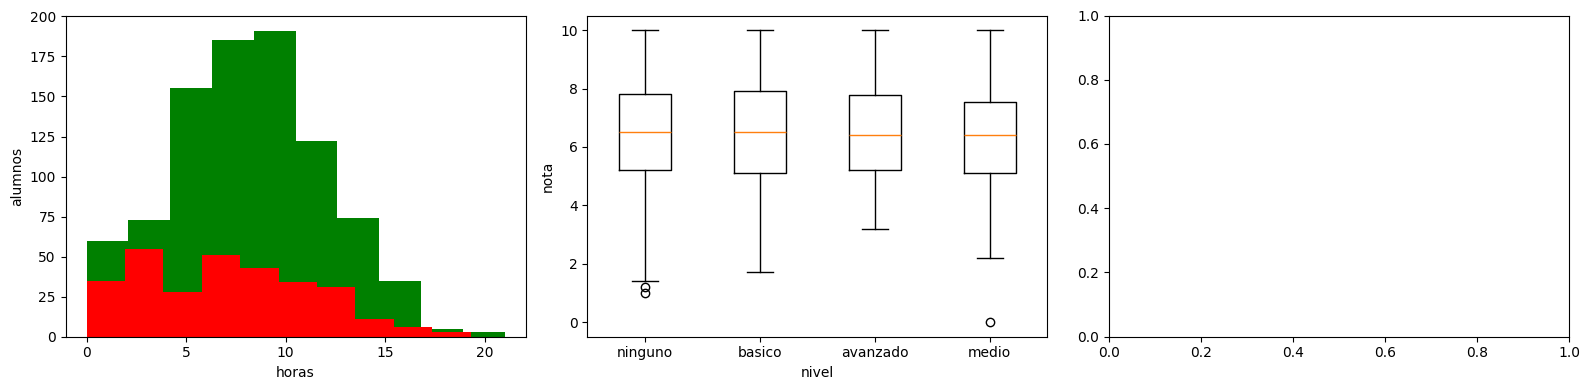

In [25]:
# EJERCICIO 2: Tres gráficos justificados
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# TODO 1: Histograma de horas_semana coloreado por abandono
axes[0].hist(df[df['abandono'] == 0]['horas_semana'], bins=10, color='green', label='no abandona')
axes[0].hist(df[df['abandono'] == 1]['horas_semana'], bins=10, color='red', label='abandona')
axes[0].set_xlabel('horas')
axes[0].set_ylabel('alumnos')

# TODO 2: Boxplot de notas_avg por nivel_previo
niveles = df['nivel_previo'].dropna().unique().tolist()

datos_box = [df[df['nivel_previo'] == n]['notas_avg'].dropna() for n in niveles]
axes[1].boxplot(datos_box, labels=niveles)
axes[1].set_xlabel('nivel')
axes[1].set_ylabel('nota')

# TODO 3: Tasa de abandono por bucket de dias_desde_ultima_conexion

plt.tight_layout()
plt.savefig('eda.png', dpi=80)
print('Gráficos generados')

In [26]:
# EJERCICIO 3: Preprocesado + Split estratificado
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

num_features = [
    'edad', 'horas_semana', 'ejercicios_completados',
    'notas_avg', 'asistencias_directos',
    'preguntas_foro', 'dias_desde_ultima_conexion',
]
cat_features = ['nivel_previo','modalidad']

# TODO: Pipeline numérico
pipeline_numerico = Pipeline([
     ('imputer', SimpleImputer(strategy='median')),
     ('scaler', StandardScaler()),
])

# TODO: Pipeline categórico
pipeline_categorico = Pipeline([
     ('imputer', SimpleImputer(strategy='most_frequent')),
     ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

# TODO: ColumnTransformer
preporcesadoor = ColumnTransformer([
     ('num', pipeline_numerico, num_features),
     ('cat', pipeline_categorico , cat_features),
])
X = df[num_features + cat_features]
y = df['abandono']

# TODO: Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, "\n")
print(y_train.mean(), y_test.mean())


(960, 9) (240, 9) 

0.24791666666666667 0.24583333333333332


In [27]:
# EJERCICIO 4: Baseline sklearn (LogReg + RandomForest)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Definir modelos en un diccionario
modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
}

# TODO: Bucle: entrenar cada uno y guardar acc + f1 + pipe + y_pred
resultados = {}
for nombre, modelo in modelos.items():
  pipe= Pipeline([
     ('prep', preporcesadoor),
     ('clf', modelo),
  ])
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  resultados[nombre] = {'pipe': pipe, 'y_pred': y_pred, 'acc': acc, 'f1': f1}
  print(nombre, acc, f1)

# TODO: Elegir el mejor por F1 y mostrar classification_report
mejor_nombre = None
mejor_f1 = -1
for nombre in resultados:
    if resultados[nombre]['f1'] > mejor_f1:
        mejor_f1 = resultados[nombre]['f1']
        mejor_nombre = nombre

print(classification_report(y_test, resultados[mejor_nombre]['y_pred'],
                            target_names=['No abandona', 'Abandona']))


LogisticRegression 0.7583333333333333 0.21621621621621623
RandomForest 0.7291666666666666 0.15584415584415584
              precision    recall  f1-score   support

 No abandona       0.77      0.96      0.86       181
    Abandona       0.53      0.14      0.22        59

    accuracy                           0.76       240
   macro avg       0.65      0.55      0.54       240
weighted avg       0.71      0.76      0.70       240



In [28]:
# EJERCICIO 5: Matriz de confusión y decisión de negocio
from sklearn.metrics import confusion_matrix

# TODO: Calcular matriz de confusión del mejor modelo
y_pred = resultados[mejor_nombre]['y_pred']
print(y_pred, "\n")

matriz = confusion_matrix(y_test, y_pred)
print(matriz, "\n")
# TODO: Extraer tn, fp, fn, tp
tn, fp, fn, tp = matriz.ravel()

print(tn, "\n")
print(fp, "\n")
print(fn, "\n")
print(tp, "\n")

# TODO: Calcular precision, recall y F1 manualmente
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * (precision * recall) / (precision + recall)

print(precision, recall, f1)

# TODO: Verificar que coinciden con classification_report

print(classification_report(y_test, y_pred, target_names=['No abandona', 'Abandona']))

[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1] 

[[174   7]
 [ 51   8]] 

174 

7 

51 

8 

0.5333333333333333 0.13559322033898305 0.21621621621621623
              precision    recall  f1-score   support

 No abandona       0.77      0.96      0.86       181
    Abandona       0.53      0.14      0.22        59

    accuracy                           0.76       240
   macro avg       0.65      0.55      0.54       240
weighted avg       0.71      0.76      0.70       240



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
0.7583333253860474 

0.2564102564102564 



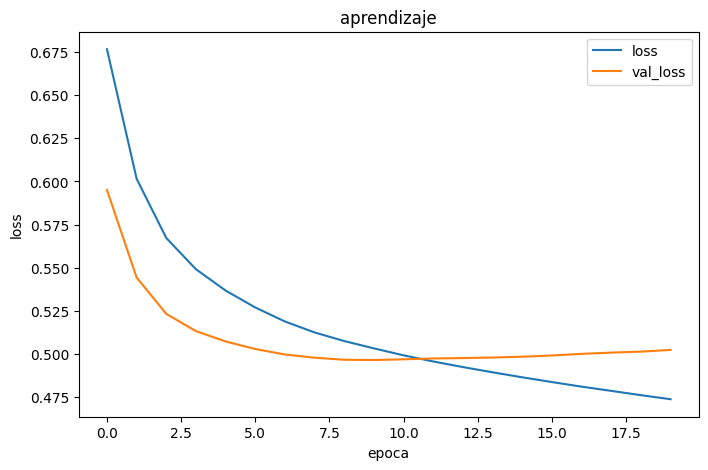

In [29]:
# EJERCICIO 6: Red neuronal Sequential (TensorFlow Tema 1)
# Nota: este ejercicio NO se ejecuta en pyodide. Cópialo a tu Jupyter local con TensorFlow instalado.

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import f1_score
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# TODO: Preprocesar X_train y X_test con el preprocessor (fit_transform / transform)
# Si la salida es sparse, convertir con .toarray()
X_train_proc = preporcesadoor.fit_transform(X_train)
X_test_proc = preporcesadoor.transform(X_test)

numero_features = X_train_proc.shape[1]

# TODO: Construir Sequential con Dense(32, relu) → Dense(16, relu) → Dense(1, sigmoid)
modelo_nn = Sequential([
  Dense(32, activation='relu', input_shape=(numero_features,)),
  Dense(16, activation='relu'),
  Dense(1, activation='sigmoid'),
])

# TODO: Compilar con adam + binary_crossentropy + accuracy
modelo_nn.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)

# TODO: fit con validation_split=0.2, epochs=20, batch_size=32, verbose=0
fit = modelo_nn.fit(X_train_proc, y_train,
                         validation_split=0.2,
                         epochs=20,
                         batch_size=32,
                         verbose=0)

# TODO: Evaluar en test y calcular F1
loss_test, acc_test = modelo_nn.evaluate(X_test_proc, y_test, verbose=0)
y_pred_nn = (modelo_nn.predict(X_test_proc) > 0.5).astype(int).ravel()
f1_nn = f1_score(y_test, y_pred_nn)

print(acc_test, "\n")
print(f1_nn, "\n")

# TODO: Pintar curva de loss y val_loss
plt.figure(figsize=(8, 5))
plt.plot(fit.history['loss'], label='loss')
plt.plot(fit.history['val_loss'], label='val_loss')
plt.xlabel('epoca')
plt.ylabel('loss')
plt.title('aprendizaje')
plt.legend()
plt.savefig('curva_loss.png', dpi=80)
plt.show()

In [31]:
# EJERCICIO 7: Comparativa final y defensa escrita
# Construye la tabla comparativa y RESPONDE las preguntas escritas en celdas markdown.
import pandas as pd

# TODO: Construir DataFrame con modelo, accuracy, F1
comparativa = pd.DataFrame([
    {'modelo': 'LogisticRegression', 'accuracy': resultados['LogisticRegression']['acc'], 'F1': resultados['LogisticRegression']['f1']},
    {'modelo': 'RandomForest', 'accuracy': resultados['RandomForest']['acc'], 'F1': resultados['RandomForest']['f1']},
    {'modelo': 'NN_Sequential', 'accuracy': acc_test, 'F1': f1_nn},
])

# TODO: Ordenar por F1 descendente
comparativa = comparativa.sort_values('F1', ascending=False).reset_index(drop=True)

# TODO: Mostrar la tabla
print(comparativa.round(3))

# TODO: Imprimir la recomendación final
print("""He comparado los tres modelos por su F1 sobre el test. Los resultados son muy
parecidos: la red neuronal obtiene 0,228, la Regresión Logística 0,216 y el
Random Forest 0,156. Aunque técnicamente la red gana por F1, lo hace por una
diferencia mínima (0,012) frente a la Regresión Logística.

Por eso recomiendo poner en producció logistica. La red neuronal
no aporta una mejora que justifique su coste, es más lenta de entrenar e inferir,
más difícil de mantener y desplegar, y es una caja negra. La regresion logistica ,
en cambio, da practicamente el mismo rendimiento siendo rápida, ligera, fácil de
desplegar e interpretable, lo que nos permite explicarla, un 1% de F1 no compensa toda esa complejidad añadida.

Debo ser honesto sobre la principal limitación: aunque el accuracy ronda el 75%,
ese número engaña, porque solo abandonan el 24,8% de los alumnos y predecir no
abandona a todos ya daría un 75%. Lo importante es el recall de la clase
abandono, que es muy bajo: el modelo deja escapar la mayoría de los alumnos que
realmente se van. Eese error (un falso negativo) es mucho más
caro que una falsa alarma, porque perder un alumno significa perder su matrícula,
mientras que avisar de más solo cuesta un email.

Por eso mi recomendación va con una mejora obligatoria: subir el recall, usando
class_weight='balanced' o bajando el umbral de decisión por debajo de 0,5.
Aceptamos más falsas alarmas a cambio de no dejar escapar abandonos reales, que
es lo que el negocio necesita. Y plantearía un seguimiento para reentrenar el
modelo si su rendimiento cae con el tiempo.""")

# --- RESPUESTAS ESCRITAS ---
# Convierte las navigatorQuestions de arriba en celdas markdown del notebook.
# La nota de este ejercicio se basa fundamentalmente en la calidad de tus respuestas.

               modelo  accuracy     F1
0       NN_Sequential     0.758  0.256
1  LogisticRegression     0.758  0.216
2        RandomForest     0.729  0.156
He comparado los tres modelos por su F1 sobre el test. Los resultados son muy
parecidos: la red neuronal obtiene 0,228, la Regresión Logística 0,216 y el
Random Forest 0,156. Aunque técnicamente la red gana por F1, lo hace por una
diferencia mínima (0,012) frente a la Regresión Logística.

Por eso recomiendo poner en producció logistica. La red neuronal
no aporta una mejora que justifique su coste, es más lenta de entrenar e inferir,
más difícil de mantener y desplegar, y es una caja negra. La regresion logistica ,
en cambio, da practicamente el mismo rendimiento siendo rápida, ligera, fácil de
desplegar e interpretable, lo que nos permite explicarla, un 1% de F1 no compensa toda esa complejidad añadida.

Debo ser honesto sobre la principal limitación: aunque el accuracy ronda el 75%,
ese número engaña, porque solo abandonan el 24,8